In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [24]:
df = pd.read_csv('/content/drive/MyDrive/CSV.file/Coffe_sales.csv')
df

,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time
0,10,card,38.70,Latte,Morning,Fri,Mar,5,3,2024-03-01,10:15:50.520000
1,12,card,38.70,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:19:22.539000
2,12,card,38.70,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:20:18.089000
3,13,card,28.90,Americano,Afternoon,Fri,Mar,5,3,2024-03-01,13:46:33.006000
4,13,card,38.70,Latte,Afternoon,Fri,Mar,5,3,2024-03-01,13:48:14.626000
...,...,...,...,...,...,...,...,...,...,...,...
3542,10,card,35.76,Cappuccino,Morning,Sun,Mar,7,3,2025-03-23,10:34:54.894000
3543,14,card,35.76,Cocoa,Afternoon,Sun,Mar,7,3,2025-03-23,14:43:37.362000
3544,14,card,35.76,Cocoa,Afternoon,Sun,Mar,7,3,2025-03-23,14:44:16.864000
3545,15,card,25.96,Americano,Afternoon,Sun,Mar,7,3,2025-03-23,15:47:28.723000


In [25]:
df = pd.read_csv('/content/drive/MyDrive/CSV.file/Coffe_sales.csv')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3547 entries, 0 to 3546
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   hour_of_day  3547 non-null   int64  
 1   cash_type    3547 non-null   object 
 2   money        3547 non-null   float64
 3   coffee_name  3547 non-null   object 
 4   Time_of_Day  3547 non-null   object 
 5   Weekday      3547 non-null   object 
 6   Month_name   3547 non-null   object 
 7   Weekdaysort  3547 non-null   int64  
 8   Monthsort    3547 non-null   int64  
 9   Date         3547 non-null   object 
 10  Time         3547 non-null   object 
dtypes: float64(1), int64(3), object(7)
memory usage: 304.9+ KB


In [26]:
df.shape

(3547, 11)

In [31]:
df.drop(['cash_type'], axis=1,inplace= True) #menghapus kolom lulus_tepat_waktu pada dataset

df

,hour_of_day,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Time
0,10,38.70,Latte,Morning,Fri,Mar,5,3,10:15:50.520000
1,12,38.70,Hot Chocolate,Afternoon,Fri,Mar,5,3,12:19:22.539000
2,12,38.70,Hot Chocolate,Afternoon,Fri,Mar,5,3,12:20:18.089000
3,13,28.90,Americano,Afternoon,Fri,Mar,5,3,13:46:33.006000
4,13,38.70,Latte,Afternoon,Fri,Mar,5,3,13:48:14.626000
...,...,...,...,...,...,...,...,...,...
3542,10,35.76,Cappuccino,Morning,Sun,Mar,7,3,10:34:54.894000
3543,14,35.76,Cocoa,Afternoon,Sun,Mar,7,3,14:43:37.362000
3544,14,35.76,Cocoa,Afternoon,Sun,Mar,7,3,14:44:16.864000
3545,15,25.96,Americano,Afternoon,Sun,Mar,7,3,15:47:28.723000


In [28]:
df.isnull().sum() #melihat missing value

#nilai 0 menandakan tidak ada missing value

,0
hour_of_day,0
cash_type,0
money,0
coffee_name,0
Time_of_Day,0
Weekday,0
Month_name,0
Weekdaysort,0
Monthsort,0
Time,0


In [32]:
df["Time_of_Day"].value_counts()

,count
Time_of_Day,
Afternoon,1205
Morning,1181
Night,1161


In [33]:
df["Weekday"].value_counts()

,count
Weekday,
Tue,572
Mon,544
Fri,532
Thu,510
Wed,500
Sat,470
Sun,419


In [34]:
df["Time_of_Day"].value_counts() / len(df) * 100

,count
Time_of_Day,
Afternoon,33.972371
Morning,33.295743
Night,32.731886


In [35]:
df.describe() # analisa statistik deskriptif

,hour_of_day,money,Weekdaysort,Monthsort
count,3547.000000,3547.000000,3547.000000,3547.000000
mean,14.185791,31.645216,3.845785,6.453905
std,4.234010,4.877754,1.971501,3.500754
min,6.000000,18.120000,1.000000,1.000000
25%,10.000000,27.920000,2.000000,3.000000
50%,14.000000,32.820000,4.000000,7.000000
75%,18.000000,35.760000,6.000000,10.000000
max,22.000000,38.700000,7.000000,12.000000


<Axes: xlabel='Weekday', ylabel='coffee_name'>

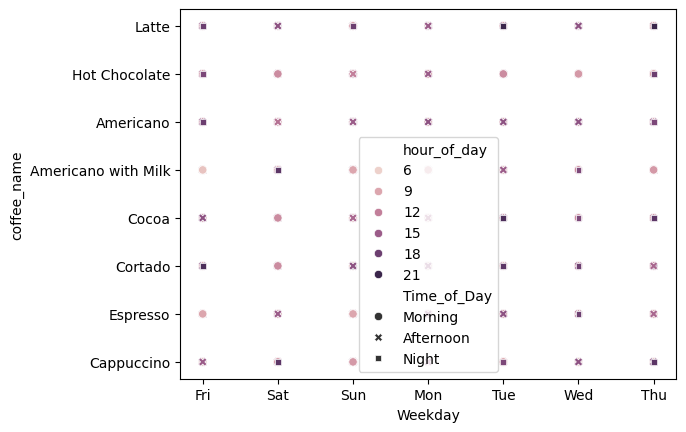

In [36]:
sns.scatterplot(data = df,
                x = "Weekday",
                y = "coffee_name",
                hue = "hour_of_day",
                style = "Time_of_Day")

In [37]:
df["coffee_name"].value_counts()

,count
coffee_name,
Americano with Milk,809
Latte,757
Americano,564
Cappuccino,486
Cortado,287
Hot Chocolate,276
Cocoa,239
Espresso,129


In [39]:
import plotly.express as px

long_df = px.data.tips()

fig = px.bar(df, x="coffee_name", y="hour_of_day", color="Time_of_Day", title="Jenis Kopi dan Waktunya")
fig.show()

[Text(0.5, 0, 'Hari Operational'),
 Text(0, 0.5, 'Total Harga'),
 Text(0.5, 1.0, 'Penjualan Kopi')]

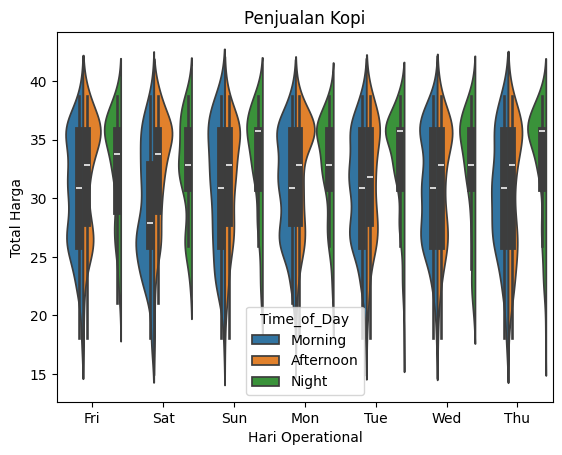

In [41]:
ax = sns.violinplot(x = "Weekday",
               y = "money",
               hue = "Time_of_Day",
               split = True,
               data = df)

ax.set(xlabel = "Hari Operational",
       ylabel = "Total Harga",
       title = "Penjualan Kopi")

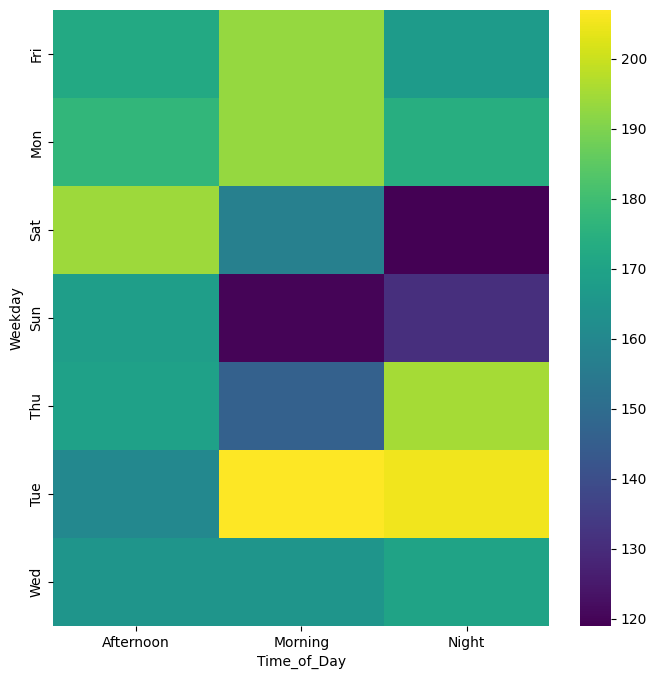

In [42]:
plt.subplots(figsize=(8, 8))
df_2dhist = pd.DataFrame({
    x_label: grp['Weekday'].value_counts()
    for x_label, grp in df.groupby('Time_of_Day')
})
sns.heatmap(df_2dhist, cmap='viridis')
plt.xlabel('Time_of_Day')
_ = plt.ylabel('Weekday')